# 先行研究の再現Part2：ベイズ推定
[PyMC公式ライブラリ](https://www.pymc.io/projects/docs/en/stable/installation.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib

print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)

2.4.2
3.0.1
3.10.8


In [2]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

In [3]:
#!pip install pymc pytensor
!pip show pymc
!pip show pytensor
!pip show arviz

Name: pymc
Version: 5.28.2
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic Machine Learning with PyTensor
Home-page: http://github.com/pymc-devs/pymc
Author: 
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: arviz, cachetools, cloudpickle, numpy, pandas, pytensor, rich, scipy, threadpoolctl, typing-extensions
Required-by: 
Name: pytensor
Version: 2.38.2
Summary: Optimizing compiler for evaluating mathematical expressions on CPUs and GPUs.
Home-page: https://github.com/pymc-devs/pytensor
Author: 
Author-email: pymc-devs <pymc.devs@gmail.com>
License-Expression: BSD-3-Clause
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: cons, etuples, filelock, logical-unification, miniKanren, numba, numpy, scipy, setuptools
Required-by: pymc
Name: arviz
Version: 0.23.4
Summary: Exploratory analysis of Bayesian models
Home-page: http://github.com/arviz-devs/arviz
Author: ArviZ 

In [4]:
import sys
print(sys.executable)

C:\Users\h20s1\workspace\.venv\Scripts\python.exe


In [5]:
import shutil
print(shutil.which("g++"))

C:\msys64\ucrt64\bin\g++.EXE


In [6]:
# read csv
from pathlib import Path
csv_path = Path("../data/raw/M.csv")
df = pd.read_csv(csv_path)

# set index to Year
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df = df.set_index("Year")
print("===to DatetimeIndex===")
print(type(df.index))
print("====DatetimeIndex====")

# normalization
df["SG_norm"] = df["D_SG"] / df["SG"] * 3000
df["IG_norm"] = df["D_IG"] / df["IG"] * 3000
df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

# view dataframe
df.head()

===to DatetimeIndex===
<class 'pandas.DatetimeIndex'>
====DatetimeIndex====


,SG,D_SG,IG,D_IG,ALL,D_ALL,SG_norm,IG_norm,ALL_norm
Year,,,,,,,,,
1920-01-01,831,25,1843,8,2674,33,90.252708,13.022246,37.023186
1921-01-01,1163,25,1833,7,2996,32,64.488392,11.456628,32.042724
1922-01-01,1305,23,1972,10,3277,33,52.873563,15.212982,30.210558
1923-01-01,1290,22,2068,5,3358,27,51.162791,7.253385,24.121501
1924-01-01,1297,37,2175,3,3472,40,85.582113,4.137931,34.562212


In [7]:
# read csv
from pathlib import Path
csv_path_para = Path("init_para/init.csv")
csv_path_y = Path("init_y/y.csv")

init_para = pd.read_csv(csv_path_para)
init_y = pd.read_csv(csv_path_y)

In [8]:
init_para

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat,lambda0_mle,alpha_mle,theta_acf,gamma_acf,lambda0_diff,alpha_diff,theta_diff,gamma_diff
0,ALL,22.745634,0.918828,0.840086,0.508958,18.1,1.4,0.89,0.64,4.645634,-0.481172,-0.049914,-0.131042
1,SG,58.528809,0.855271,0.812694,0.566471,42.4,1.6,0.88,0.63,16.128809,-0.744729,-0.067306,-0.063529
2,IG,2.090132,1.202780,0.745700,0.685032,0.6,2.5,0.84,0.74,1.490132,-1.297220,-0.094300,-0.054968


In [9]:
init_y["Year"] = pd.to_datetime(init_y["Year"])
init_y = init_y.set_index("Year")

print(type(init_y.index))

<class 'pandas.DatetimeIndex'>


In [10]:
init_y.head()

,ALL,SG,IG
Year,,,
1920-01-01,0.544809,0.512842,1.552328
1921-01-01,0.389823,0.122405,1.450023
1922-01-01,0.326757,-0.107806,1.677164
1923-01-01,0.086248,-0.145897,1.089893
1924-01-01,0.470981,0.451065,0.662666


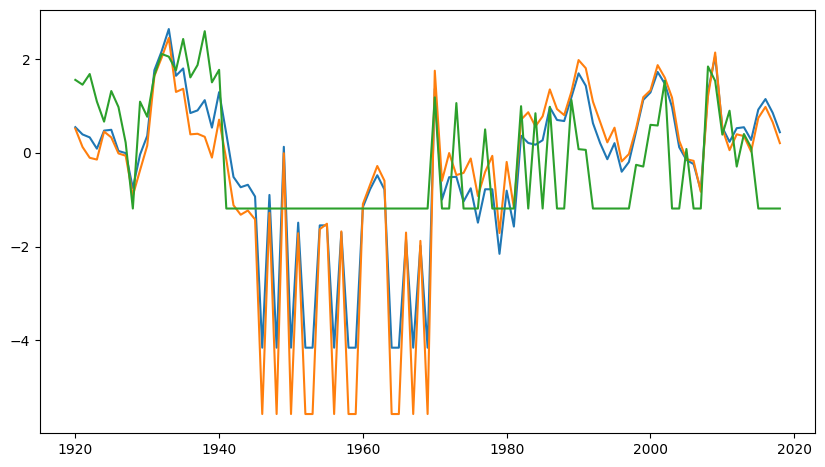

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5.5))
plt.plot(init_y)

In [13]:
init_para_fit = init_para[
    ["group", "lambda0_init", "alpha0_init", "theta_hat", "gamma_hat"]
]
init_para_fit

,group,lambda0_init,alpha0_init,theta_hat,gamma_hat
0,ALL,22.745634,0.918828,0.840086,0.508958
1,SG,58.528809,0.855271,0.812694,0.566471
2,IG,2.090132,1.202780,0.745700,0.685032


In [14]:
init_para_paper = init_para[
    ["group", "lambda0_mle", "alpha_mle", "theta_acf", "gamma_acf"]
]
init_para_paper

,group,lambda0_mle,alpha_mle,theta_acf,gamma_acf
0,ALL,18.1,1.4,0.89,0.64
1,SG,42.4,1.6,0.88,0.63
2,IG,0.6,2.5,0.84,0.74


In [15]:
row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]

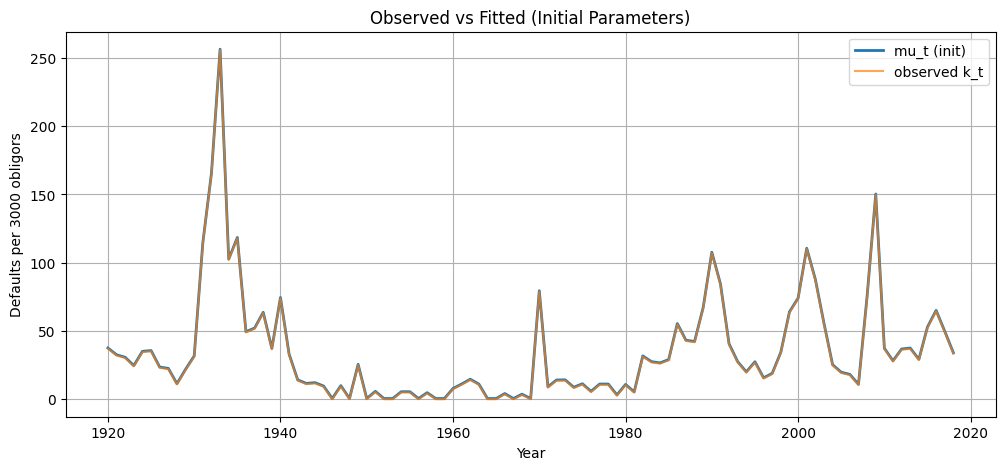

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 初期パラメータ ---
lambda0_init = float(row_all["lambda0_init"])
alpha_init = float(row_all["alpha0_init"])
eta0_init = np.log(lambda0_init)

# --- 初期y ---
y_init_all = init_y["ALL"].values

# --- 観測 ---
k_obs = df["ALL_norm"].to_numpy()

# --- 強度 ---
mu_init = np.exp(eta0_init + alpha_init * y_init_all)

# --- 年 ---
years = df.index

# --- プロット ---
plt.figure(figsize=(12, 5))

plt.plot(years, mu_init, label="mu_t (init)", linewidth=2)
plt.plot(years, k_obs, label="observed k_t", alpha=0.7)

plt.title("Observed vs Fitted (Initial Parameters)")
plt.xlabel("Year")
plt.ylabel("Defaults per 3000 obligors")
plt.legend()
plt.grid(True)

plt.show()

## パラメータの事前分布
$$
X_t|(\lambda_0 , \alpha) , \vec{y}\sim   \text{Poisson}\left(\exp{(\eta_0 + \alpha y_t)}\right)\ , \ \eta_0 \sim \mathcal{N}(\mu_{\eta_0} , \sigma^2_{\eta_0})\ ,\ \alpha \sim \mathcal{N}(\mu_{\alpha} , \sigma^2_{\alpha})
\
$$
なお、モデルとして自然にするために$\eta_0 = \log{\lambda_0}$とした

In [17]:
# データ準備
k_data = df["ALL_norm"].to_numpy(dtype=float)
y_fixed = init_y["ALL"].to_numpy(dtype=float)

# 長さチェック
assert len(k_data) == len(y_fixed), "k_data と y_fixed の長さが一致していません"

# Poisson の observed は整数カウントが自然なので丸める
k_obs = np.rint(k_data).astype("int64")

# 初期値（ALL行）
row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]
lambda0_init = float(row_all["lambda0_init"])
alpha_init = float(row_all["alpha0_init"])
theta_init = float(row_all["theta_hat"])
eta0_init = float(np.log(lambda0_init))

# y の初期値
y_init = init_y["ALL"].to_numpy(dtype=float)

In [18]:
row_all

group                 ALL
lambda0_init    22.745634
alpha0_init      0.918828
theta_hat        0.840086
gamma_hat        0.508958
Name: 0, dtype: object

## 指数減衰モデル
$$
\ y_t = \theta y_{t-1} + \sqrt{1 - \theta^2} \xi_t \ , \ y_1 \sim \ \mathcal{N}(0,1), \ \xi_t \sim \mathcal{N}(0,1) \ ,\ \theta \sim \text{Beta}(a,b)
$$

PyMCでの作成モデル

$$
p(\eta_0, \alpha, \theta, y_{1:T} \mid x_{1:T})
$$

の同時事後分布のmode（最大値）を求める。

つまり

$$
\mathrm{MAP}
=
\arg\max_{\eta_0, \alpha, \theta, y}
\left[
\log p(x \mid y, \eta_0, \alpha)
+
\log p(y \mid \theta)
+
\log p(\eta_0, \alpha, \theta)
\right]
$$

In [19]:
k_obs = np.asarray(k_obs, dtype="int64")
T = len(k_obs)

eta0_init = float(np.log(lambda0_init))
alpha_init = float(alpha_init)
theta0 = float(theta_init)
y0 = np.asarray(y_init, dtype=float)

kappa = 30.0
a_theta = 1.0 + kappa * theta0
b_theta = 1.0 + kappa * (1.0 - theta0)

with pm.Model() as model_map_theta_free:
    # 第三項
    eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
    alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
    theta = pm.Beta("theta", alpha=a_theta, beta=b_theta)

    # y_0
    y = pm.Normal("y", mu=0.0, sigma=1.0, shape=T)

    sigma_y = pm.math.sqrt(1.0 - theta**2)

    # 第二項
    logp_y1 = pm.logp(pm.Normal.dist(mu=0.0, sigma=1.0), y[0])
    logp_trans = pm.logp(
        pm.Normal.dist(mu=theta * y[:-1], sigma=sigma_y),
        y[1:]
    ).sum()

    pm.Potential("ar1_prior", logp_y1 + logp_trans)

    # 第一項
    mu = pm.math.exp(eta0 + alpha * y)
    x = pm.Poisson("x", mu=mu, observed=k_obs)

    start = {
        "eta0": eta0_init,
        "alpha": alpha_init,
        "theta_logodds__": np.log(theta0 / (1.0 - theta0)),
        "y": y0,
    }

    map_est = pm.find_MAP(start=start)

theta_map = 1.0 / (1.0 + np.exp(-map_est["theta_logodds__"]))

print("eta0_map =", map_est["eta0"])
print("lambda0_map =", np.exp(map_est["eta0"]))
print("alpha_map =", map_est["alpha"])
print("theta_map =", theta_map)

C:\Users\h20s1\workspace\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

eta0_map = 3.001128112773687
lambda0_map = 20.108208459577586
alpha_map = 3.4903579109644745
theta_map = 0.9815842420148914


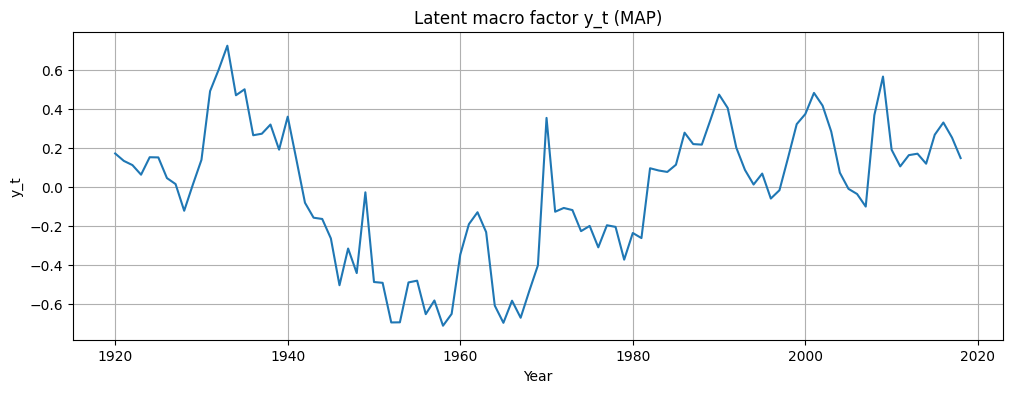

In [20]:
y_map = map_est["y"]
years = df.index  # DatetimeIndexなど

plt.figure(figsize=(12, 4))
plt.plot(years, y_map)
plt.title("Latent macro factor y_t (MAP)")
plt.xlabel("Year")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

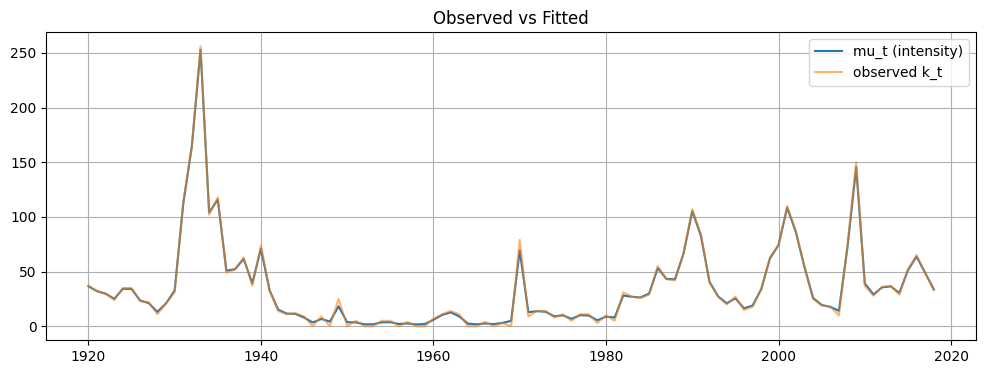

In [21]:
eta0_map = map_est["eta0"]
alpha_map = map_est["alpha"]

mu_map = np.exp(eta0_map + alpha_map * y_map)

plt.figure(figsize=(12, 4))
plt.plot(years, mu_map, label="mu_t (intensity)")
plt.plot(years, k_obs, label="observed k_t", alpha=0.6)
plt.legend()
plt.title("Observed vs Fitted")
plt.grid(True)
plt.show()

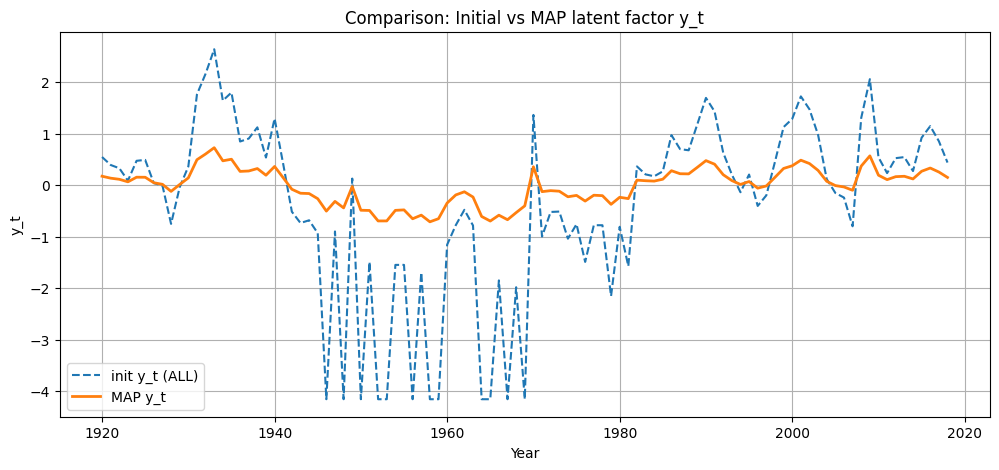

In [22]:
# MAPのy
y_map = map_est["y"]

# 初期値（ALL）
y_init_all = init_y["ALL"].values

# 年
years = init_y.index

plt.figure(figsize=(12, 5))

plt.plot(years, y_init_all, label="init y_t (ALL)", linestyle="--")
plt.plot(years, y_map, label="MAP y_t", linewidth=2)

plt.legend()
plt.title("Comparison: Initial vs MAP latent factor y_t")
plt.xlabel("Year")
plt.ylabel("y_t")
plt.grid(True)

plt.show()

In [23]:
corr = np.corrcoef(y_init_all, y_map)[0, 1]
print("correlation =", corr)

correlation = 0.9486747163945183


マクロ要因として自然な$y_t$が推定できた

## べき乗減衰モデル
$$
d_h = \frac{1}{(1+h)^\gamma}, \gamma \sim \text{Ga}(a,b)
$$

In [24]:
import numpy as np
import pymc as pm
import pytensor.tensor as pt

# =========================
# データ準備
# =========================
k_data = df["ALL_norm"].to_numpy(dtype=float)
k_obs = np.rint(k_data).astype("int64")

row_all = init_para_fit.loc[init_para_fit["group"] == "ALL"].iloc[0]

lambda0_init = float(row_all["lambda0_init"])
alpha_init = float(row_all["alpha0_init"])
gamma_init = float(row_all["gamma_hat"])   # 0.508958 を想定
eta0_init = float(np.log(lambda0_init))

y_init = init_y["ALL"].to_numpy(dtype=float)

k_obs = np.asarray(k_obs, dtype="int64")
y0 = np.asarray(y_init, dtype=float)
T = len(k_obs)

assert len(y0) == T, "k_obs と y_init の長さが一致していません"

# =========================
# gamma prior の設定
# mode = gamma_init になる Gamma(shape-rate)
# mode = (alpha_gamma - 1) / beta_gamma
# =========================
c_gamma = 10.0
alpha_gamma = 1.0 + c_gamma
beta_gamma = c_gamma / gamma_init

print("gamma_init       =", gamma_init)
print("alpha_gamma      =", alpha_gamma)
print("beta_gamma       =", beta_gamma)
print("prior_mode_gamma =", (alpha_gamma - 1.0) / beta_gamma)

# =========================
# MAP model
# =========================
with pm.Model() as model_map_gamma_free:
    # 第三項: パラメータ事前
    eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
    alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
    gamma = pm.Gamma("gamma", alpha=alpha_gamma, beta=beta_gamma)

    # 相関行列 Sigma_gamma
    idx = pt.arange(T)
    lags = pt.abs(idx[:, None] - idx[None, :])   # |i-j|
    Sigma = (1.0 + lags) ** (-gamma)

    # 数値安定化のため jitter を追加
    jitter = 1e-6
    Sigma = Sigma + jitter * pt.eye(T)

    # 第二項: y の多変量正規事前
    y = pm.MvNormal("y", mu=pt.zeros(T), cov=Sigma, shape=T)

    # 第一項: 尤度
    mu = pm.math.exp(eta0 + alpha * y)
    x = pm.Poisson("x", mu=mu, observed=k_obs)

    # start
    start = {
        "eta0": eta0_init,
        "alpha": alpha_init,
        "gamma_log__": np.log(gamma_init),
        "y": y0,
    }

    map_est = pm.find_MAP(start=start)

gamma_map = np.exp(map_est["gamma_log__"])

print("eta0_map    =", map_est["eta0"])
print("lambda0_map =", np.exp(map_est["eta0"]))
print("alpha_map   =", map_est["alpha"])
print("gamma_map   =", gamma_map)

gamma_init       = 0.5089581516717917
alpha_gamma      = 11.0
beta_gamma       = 19.64798081561847
prior_mode_gamma = 0.5089581516717917


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

eta0_map    = 3.1254316912384783
lambda0_map = 22.769722461869076
alpha_map   = 3.1747181611542534
gamma_map   = 0.05147388110799116


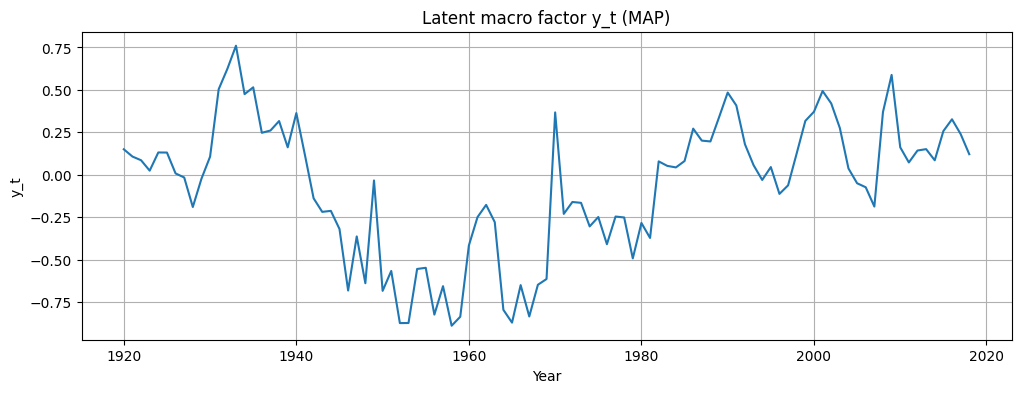

In [25]:
y_map = map_est["y"]
years = df.index  # DatetimeIndexなど

plt.figure(figsize=(12, 4))
plt.plot(years, y_map)
plt.title("Latent macro factor y_t (MAP)")
plt.xlabel("Year")
plt.ylabel("y_t")
plt.grid(True)
plt.show()

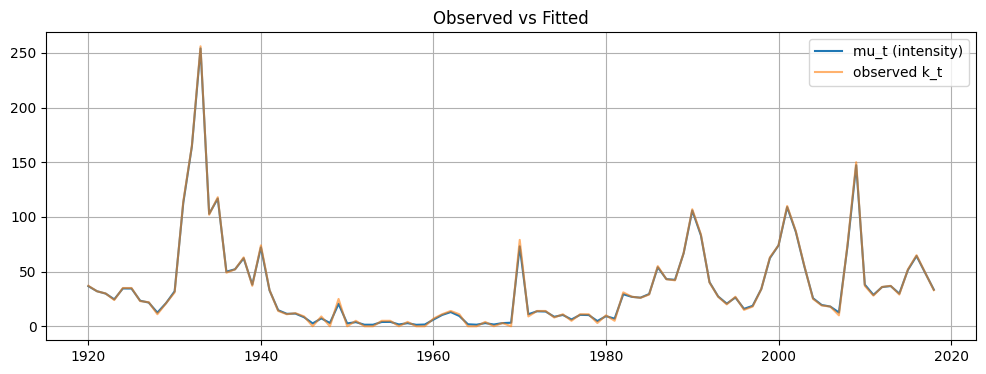

In [26]:
eta0_map = map_est["eta0"]
alpha_map = map_est["alpha"]

mu_map = np.exp(eta0_map + alpha_map * y_map)

plt.figure(figsize=(12, 4))
plt.plot(years, mu_map, label="mu_t (intensity)")
plt.plot(years, k_obs, label="observed k_t", alpha=0.6)
plt.legend()
plt.title("Observed vs Fitted")
plt.grid(True)
plt.show()

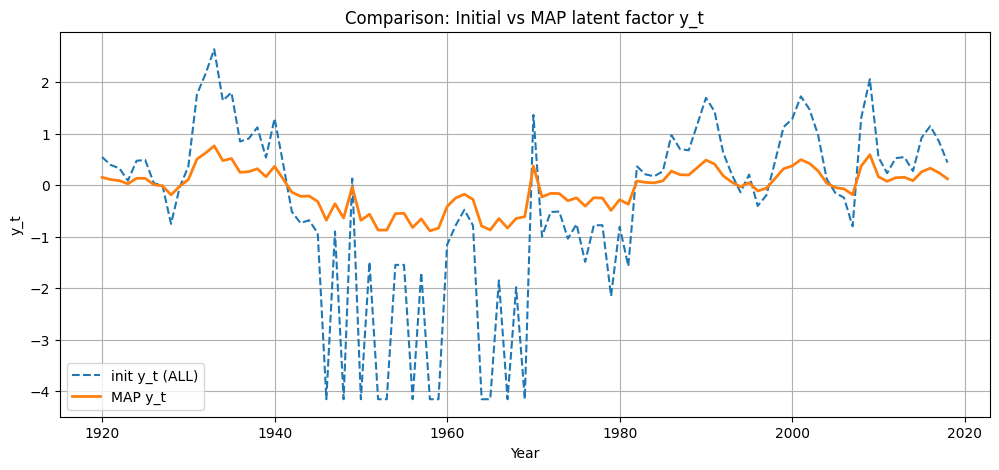

In [27]:
# MAPのy
y_map = map_est["y"]

# 初期値（ALL）
y_init_all = init_y["ALL"].values

# 年
years = init_y.index

plt.figure(figsize=(12, 5))

plt.plot(years, y_init_all, label="init y_t (ALL)", linestyle="--")
plt.plot(years, y_map, label="MAP y_t", linewidth=2)

plt.legend()
plt.title("Comparison: Initial vs MAP latent factor y_t")
plt.xlabel("Year")
plt.ylabel("y_t")
plt.grid(True)

plt.show()

In [28]:
corr = np.corrcoef(y_init_all, y_map)[0, 1]
print("correlation =", corr)

correlation = 0.9669702364596668


## モデルの評価

In [29]:
# WAIC
import numpy as np
import pymc as pm
import arviz as az
import pytensor.tensor as pt

def build_exp_model(k_obs, eta0_init, alpha_init, theta0, y0, kappa=30.0):
    T = len(k_obs)

    a_theta = 1.0 + kappa * theta0
    b_theta = 1.0 + kappa * (1.0 - theta0)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
        theta = pm.Beta("theta", alpha=a_theta, beta=b_theta)

        y = pm.Normal("y", mu=0.0, sigma=1.0, shape=T)

        sigma_y = pm.math.sqrt(1.0 - theta**2)

        logp_y1 = pm.logp(pm.Normal.dist(mu=0.0, sigma=1.0), y[0])
        logp_trans = pm.logp(
            pm.Normal.dist(mu=theta * y[:-1], sigma=sigma_y),
            y[1:]
        ).sum()
        pm.Potential("ar1_prior", logp_y1 + logp_trans)

        mu = pm.math.exp(eta0 + alpha * y)
        pm.Poisson("x", mu=mu, observed=k_obs)

    return model

def build_pow_model(k_obs, eta0_init, alpha_init, gamma_init, y0, c_gamma=10.0):
    T = len(k_obs)

    alpha_gamma = 1.0 + c_gamma
    beta_gamma = c_gamma / gamma_init

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
        gamma = pm.Gamma("gamma", alpha=alpha_gamma, beta=beta_gamma)

        idx = pt.arange(T)
        lags = pt.abs(idx[:, None] - idx[None, :])
        Sigma = (1.0 + lags) ** (-gamma)
        Sigma = Sigma + 1e-6 * pt.eye(T)

        y = pm.MvNormal("y", mu=pt.zeros(T), cov=Sigma, shape=T)

        mu = pm.math.exp(eta0 + alpha * y)
        pm.Poisson("x", mu=mu, observed=k_obs)

    return model

with build_exp_model(k_obs, eta0_init, alpha_init, theta_init, y0) as exp_model:
    idata_exp = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

with build_pow_model(k_obs, eta0_init, alpha_init, gamma_init, y0) as pow_model:
    idata_pow = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True,
        idata_kwargs={"log_likelihood": True}
    )

waic_exp = az.waic(idata_exp)
waic_pow = az.waic(idata_pow)

print("WAIC exp =", waic_exp.elpd_waic, waic_exp.p_waic)
print("WAIC pow =", waic_pow.elpd_waic, waic_pow.p_waic)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, theta, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 24 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 152 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


WAIC exp = -332.31658776794586 57.19481415166931
WAIC pow = -324.4616736438316 54.944108668728916


C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
C:\Users\h20s1\workspace\.venv\Lib\site-packages\arviz\stats\stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [30]:
waic_exp_value = -2.0 * waic_exp.elpd_waic
waic_pow_value = -2.0 * waic_pow.elpd_waic

print("WAIC(exp) =", waic_exp_value)
print("WAIC(pow) =", waic_pow_value)

WAIC(exp) = 664.6331755358917
WAIC(pow) = 648.9233472876632


In [31]:
# WBIC
def build_exp_model_wbic(k_obs, eta0_init, alpha_init, theta0, y0, beta_temp, kappa=30.0):
    T = len(k_obs)
    a_theta = 1.0 + kappa * theta0
    b_theta = 1.0 + kappa * (1.0 - theta0)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
        theta = pm.Beta("theta", alpha=a_theta, beta=b_theta)

        y = pm.Normal("y", mu=0.0, sigma=1.0, shape=T)

        sigma_y = pm.math.sqrt(1.0 - theta**2)
        logp_y1 = pm.logp(pm.Normal.dist(mu=0.0, sigma=1.0), y[0])
        logp_trans = pm.logp(
            pm.Normal.dist(mu=theta * y[:-1], sigma=sigma_y),
            y[1:]
        ).sum()
        pm.Potential("ar1_prior", logp_y1 + logp_trans)

        mu = pm.math.exp(eta0 + alpha * y)

        ll_vec = pm.logp(pm.Poisson.dist(mu=mu), k_obs)
        pm.Deterministic("loglik_pointwise", ll_vec)
        pm.Potential("tempered_like", beta_temp * ll_vec.sum())

    return model

def build_pow_model_wbic(k_obs, eta0_init, alpha_init, gamma_init, y0, beta_temp, c_gamma=10.0):
    T = len(k_obs)

    alpha_gamma = 1.0 + c_gamma
    beta_gamma = c_gamma / gamma_init

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=eta0_init, sigma=0.5)
        alpha = pm.Normal("alpha", mu=alpha_init, sigma=0.3)
        gamma = pm.Gamma("gamma", alpha=alpha_gamma, beta=beta_gamma)

        idx = pt.arange(T)
        lags = pt.abs(idx[:, None] - idx[None, :])
        Sigma = (1.0 + lags) ** (-gamma)
        Sigma = Sigma + 1e-6 * pt.eye(T)

        y = pm.MvNormal("y", mu=pt.zeros(T), cov=Sigma, shape=T)

        mu = pm.math.exp(eta0 + alpha * y)

        ll_vec = pm.logp(pm.Poisson.dist(mu=mu), k_obs)
        pm.Deterministic("loglik_pointwise", ll_vec)
        pm.Potential("tempered_like", beta_temp * ll_vec.sum())

    return model

n = len(k_obs)
beta_temp = 1.0 / np.log(n)

with build_exp_model_wbic(k_obs, eta0_init, alpha_init, theta_init, y0, beta_temp) as exp_wbic_model:
    idata_exp_wbic = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True
    )

with build_pow_model_wbic(k_obs, eta0_init, alpha_init, gamma_init, y0, beta_temp) as pow_wbic_model:
    idata_pow_wbic = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        return_inferencedata=True
    )

ll_exp = idata_exp_wbic.posterior["loglik_pointwise"].sum(dim="loglik_pointwise_dim_0")
ll_pow = idata_pow_wbic.posterior["loglik_pointwise"].sum(dim="loglik_pointwise_dim_0")

wbic_exp = -2.0 * ll_exp.mean().item()
wbic_pow = -2.0 * ll_pow.mean().item()

print("WBIC(exp) =", wbic_exp)
print("WBIC(pow) =", wbic_pow)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, theta, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [eta0, alpha, gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 81 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


WBIC(exp) = 918.5602825081102
WBIC(pow) = 887.332595267578


In [ ]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.special import gammaln, logsumexp

# =========================================================
# 共通関数
# =========================================================
def poisson_logpmf_vec(x, mu):
    x = np.asarray(x, dtype=float)
    mu = np.asarray(mu, dtype=float)
    mu = np.clip(mu, 1e-12, None)
    return x * np.log(mu) - mu - gammaln(x + 1)


def beta_ab_from_mode_sc(mode, sc, eps=1e-6):
    """
    Beta(a,b) の mode が mode になるようにしつつ、
    sc で事前分布の鋭さを調整する
    """
    m = float(np.clip(mode, eps, 1.0 - eps))
    sc = float(sc)
    a = 1.0 + sc * m
    b = 1.0 + sc * (1.0 - m)
    return a, b


def powerlaw_corr_matrix(T, gamma, eps=1e-6):
    """
    C_ij = (1 + |i-j|)^(-gamma)
    対角は1。
    数値安定のため微小の jitter を足す。
    """
    idx = np.arange(T)
    lag = np.abs(idx[:, None] - idx[None, :]).astype(float)
    C = (1.0 + lag) ** (-gamma)
    C = C + eps * np.eye(T)
    return C


# =========================================================
# exp モデル
# =========================================================
def build_exp_model(k_obs, eta0_init, alpha_init, theta_init, y_init, sc):
    k_obs = np.asarray(k_obs, dtype="int64")
    y_init = np.asarray(y_init, dtype=float)
    T = len(k_obs)

    a_theta, b_theta = beta_ab_from_mode_sc(theta_init, sc)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=float(eta0_init), sigma=0.5, initval=float(eta0_init))
        alpha = pm.Normal("alpha", mu=float(alpha_init), sigma=0.3, initval=float(alpha_init))
        theta = pm.Beta("theta", alpha=a_theta, beta=b_theta, initval=float(theta_init))

        y = pm.Normal("y", mu=0.0, sigma=1.0, shape=T, initval=y_init)

        sigma_y = pt.sqrt(pt.maximum(1e-12, 1.0 - theta**2))

        logp_y0 = pm.logp(pm.Normal.dist(mu=0.0, sigma=1.0), y[0])
        logp_trans = pt.sum(
            pm.logp(
                pm.Normal.dist(mu=theta * y[:-1], sigma=sigma_y),
                y[1:]
            )
        )
        pm.Potential("ar1_prior", logp_y0 + logp_trans)

        mu = pt.exp(eta0 + alpha * y)
        pm.Poisson("x", mu=mu, observed=k_obs)

    return model


def one_step_lfo_score_exp(idata, x_next, n_sim=50, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    eta0 = idata.posterior["eta0"].values.reshape(-1)
    alpha = idata.posterior["alpha"].values.reshape(-1)
    theta = idata.posterior["theta"].values.reshape(-1)
    y_last = idata.posterior["y"].values[..., -1].reshape(-1)

    S = len(eta0)
    log_terms = []

    for s in range(S):
        sigma = np.sqrt(max(1e-12, 1.0 - theta[s] ** 2))
        y_next_sim = rng.normal(loc=theta[s] * y_last[s], scale=sigma, size=n_sim)
        mu_next_sim = np.exp(eta0[s] + alpha[s] * y_next_sim)

        ll = poisson_logpmf_vec(x_next, mu_next_sim)
        log_terms.append(logsumexp(ll) - np.log(n_sim))

    log_pred = logsumexp(np.asarray(log_terms)) - np.log(S)
    return -log_pred


def run_lfo_exp(k_obs, t0_grid, eta0_init, alpha_init, theta_init, y0, sc,
                draws=1000, tune=1000, chains=4, target_accept=0.95):
    scores = []
    T = len(k_obs)

    for t0 in t0_grid:
        if t0 >= T:
            continue

        k_train = np.asarray(k_obs[:t0], dtype="int64")
        x_next = int(k_obs[t0])
        y0_train = np.asarray(y0[:t0], dtype=float)

        with build_exp_model(k_train, eta0_init, alpha_init, theta_init, y0_train, sc):
            idata = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                target_accept=target_accept,
                progressbar=False,
                return_inferencedata=True
            )

        score = one_step_lfo_score_exp(idata, x_next)
        scores.append(score)

    return float(np.sum(scores)), scores


# =========================================================
# power-law モデル
# =========================================================
def build_pow_model(k_obs, eta0_init, alpha_init, gamma_init, y_init, sc):
    """
    潜在因子 y に power-law 相関をもつ多変量正規 prior を入れる版。
    Corr(y_i, y_j) = (1 + |i-j|)^(-gamma)
    gamma の prior は mode(gamma)=gamma_init, 強さ=sc の Beta。
    """
    k_obs = np.asarray(k_obs, dtype="int64")
    y_init = np.asarray(y_init, dtype=float)
    T = len(k_obs)

    a_gamma, b_gamma = beta_ab_from_mode_sc(gamma_init, sc)

    # 固定された lag 行列を事前に作る
    lag_mat = np.abs(np.arange(T)[:, None] - np.arange(T)[None, :]).astype(float)

    with pm.Model() as model:
        eta0 = pm.Normal("eta0", mu=float(eta0_init), sigma=0.5, initval=float(eta0_init))
        alpha = pm.Normal("alpha", mu=float(alpha_init), sigma=0.3, initval=float(alpha_init))

        # gamma は更新される推定対象
        gamma = pm.Beta("gamma", alpha=a_gamma, beta=b_gamma, initval=float(gamma_init))

        # power-law covariance
        Sigma = pt.power(1.0 + pt.as_tensor_variable(lag_mat), -gamma)
        Sigma = Sigma + 1e-6 * pt.eye(T)

        # latent states: 多変量正規で power-law 相関を直接入れる
        y = pm.MvNormal("y", mu=pt.zeros(T), cov=Sigma, shape=T, initval=y_init)

        mu = pt.exp(eta0 + alpha * y)
        pm.Poisson("x", mu=mu, observed=k_obs)

    return model


def one_step_lfo_score_pow_approx(idata, x_next):
    """
    簡易版:
    y_{t+1} ≈ y_t とみなす近似
    """
    eta0 = idata.posterior["eta0"].values.reshape(-1)
    alpha = idata.posterior["alpha"].values.reshape(-1)
    y_last = idata.posterior["y"].values[..., -1].reshape(-1)

    mu_next = np.exp(eta0 + alpha * y_last)
    log_pred = logsumexp(poisson_logpmf_vec(x_next, mu_next)) - np.log(len(mu_next))
    return -log_pred


def run_lfo_pow(k_obs, t0_grid, eta0_init, alpha_init, gamma_init, y0, sc,
                draws=1000, tune=1000, chains=4, target_accept=0.95):
    scores = []
    T = len(k_obs)

    for t0 in t0_grid:
        if t0 >= T:
            continue

        k_train = np.asarray(k_obs[:t0], dtype="int64")
        x_next = int(k_obs[t0])
        y0_train = np.asarray(y0[:t0], dtype=float)

        with build_pow_model(k_train, eta0_init, alpha_init, gamma_init, y0_train, sc):
            idata = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                target_accept=target_accept,
                progressbar=False,
                return_inferencedata=True
            )

        score = one_step_lfo_score_pow_approx(idata, x_next)
        scores.append(score)

    return float(np.sum(scores)), scores


# =========================================================
# 実行部
# =========================================================
sc_list = [1, 2, 3, 4, 5, 10, 20]
results = []

T = len(k_obs)
t0_grid = [t0 for t0 in range(50, 101, 5) if t0 < T]

for sc in sc_list:
    lfo_exp_total, _ = run_lfo_exp(
        k_obs=k_obs,
        t0_grid=t0_grid,
        eta0_init=eta0_init,
        alpha_init=alpha_init,
        theta_init=theta_init,
        y0=y0,
        sc=sc,
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.95
    )

    lfo_pow_total, _ = run_lfo_pow(
        k_obs=k_obs,
        t0_grid=t0_grid,
        eta0_init=eta0_init,
        alpha_init=alpha_init,
        gamma_init=gamma_init,
        y0=y0,
        sc=sc,
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.95
    )

    results.append({
        "sc": sc,
        "lfo_exp": lfo_exp_total,
        "lfo_pow": lfo_pow_total
    })

df_lfo = pd.DataFrame(results)

print(df_lfo)
print("\n=== sort by lfo_exp ===")
print(df_lfo.sort_values("lfo_exp"))
print("\n=== sort by lfo_pow ===")
print(df_lfo.sort_values("lfo_pow"))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, theta, y]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 45 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, theta, y]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some

In [ ]:
# まとめ
summary = pd.DataFrame({
    "model": ["exp", "pow"],
    "WAIC": [waic_exp_value, waic_pow_value],
    "WBIC": [wbic_exp, wbic_pow],
    "LFO": [lfo_exp_total, lfo_pow_total],
})

print(summary)